# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering
   - 3a. Estelle's feature: off-peak price difference (Dec vs. Jan)
   - 3b. Date-based features
   - 3c. Consumption-based features
   - 3d. Price variation features
   - 3e. Financial & margin features
   - 3f. Categorical encoding
4. Merge all features & validate
5. Save final dataset

---

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress display warnings
import warnings
warnings.filterwarnings('ignore')

All packages imported.


---
## 2. Load data

In [2]:
# Load main client dataset
df = pd.read_csv('./clean_data_after_eda.csv')

# "Convert all date columns at the beginning."
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

print(f'Client data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Client data loaded: 14,606 rows x 44 columns


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


In [3]:
# Load the price history dataset (this is necessary for Estelle's feature in section 3a).
price_df = pd.read_csv('./price_data.csv')
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

print(f'Price data loaded: {price_df.shape[0]:,} rows x {price_df.shape[1]} columns')
price_df.head()

Price data loaded: 193,002 rows x 8 columns


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


---
## 3. Feature Engineering

### 3a. Estelle's Feature: Off-Peak Price Difference (December vs. January)

Estelle hypothesizes that a significant fluctuation in off-peak prices between December and the preceding January indicates pricing instability, which may lead to customer churn.

We calculate this difference separately for the **variable** component (`price_off_peak_var`) and the **fixed** component (`price_off_peak_fix`).

In [4]:
# Combine data into a single row for each company and month, averaging any variations that occur within the month.
monthly_price_by_id = (
    price_df
    .groupby(['id', 'price_date'])
    .agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'})
    .reset_index()
)

# January marks the first recorded month for each company, while December marks the last recorded month.
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Combine the data and calculate the difference between December and January.
diff = pd.merge(
    dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}),
    jan_prices.drop(columns='price_date'),
    on='id'
)

diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power']  = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']]

print(f'Estelle features computed for {len(diff):,} companies.')
diff.head()

Estelle features computed for 16,096 companies.


,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


### 3b. Date-Based Features  

Contract dates hold significant information regarding customer loyalty and the risk of churn. A customer approaching the end of their contract is more likely to churn compared to one who is in the middle of their contract. Additionally, a customer whose product was recently modified may be responding to a price change.  

We use `date_end` as our reference point because it represents the most recent recorded date and serves as a natural snapshot for each customer.

In [5]:
# 1. Customer tenure in months. How long has this customer been active? 
# A longer tenure often correlates with a lower churn probability.
df['tenure_months'] = (
    (df['date_end'] - df['date_activ']).dt.days / 30.44
).round(1)

#Months since the last product modification indicate recent changes. 
#A recent modification may suggest a customer is testing alternatives.
df['months_since_last_modif'] = (
    (df['date_end'] - df['date_modif_prod']).dt.days / 30.44
).round(1)

# 3. Months between renewal and contract end date:
# A large positive gap indicates early renewal, signaling stability.
# A negative or near-zero gap suggests last-minute renewal.
df['renewal_to_end_months'] = (
    (df['date_end'] - df['date_renewal']).dt.days / 30.44
).round(1)

# 4. Contract end month (1-12) — this variable captures seasonal trends in churn decisions.
df['contract_end_month'] = df['date_end'].dt.month

# 5. Was the product modified in the last 6 months?  
# Binary flag: recent changes may indicate customer dissatisfaction or retention efforts.
df['modified_recently'] = (
    df['months_since_last_modif'] <= 6
).astype(int)

#6. Activation quarter.which quarter of the year did the customer first sign up?
df['activation_quarter'] = df['date_activ'].dt.quarter

print('Date-based features created.')
df[['id', 'tenure_months', 'months_since_last_modif',
    'renewal_to_end_months', 'contract_end_month',
    'modified_recently', 'activation_quarter']].head()

Date-based features created.


,id,tenure_months,months_since_last_modif,renewal_to_end_months,contract_end_month,modified_recently,activation_quarter
0,24011ae4ebbe3035111d65fa7c15bc57,36.0,7.5,11.8,6,0,2
1,d29c2c54acc38ff3c0614d0a653813dd,84.3,84.3,12.0,8,0,3
2,764c75f661154dac3a6c254cd082ea7d,72.0,72.0,12.0,4,0,2
3,bba03439a292a1e166f80264c16191cb,72.0,72.0,12.0,3,0,1
4,149d57cf92fc41cf94415803a877cb4b,73.8,73.8,12.0,3,0,1


### 3c. Consumption-based Features

Energy consumption patterns provide valuable insights into customer behavior. Customers with unusually low or zero consumption in the last month may be leaving. Customers with bundled gas and electricity services face higher switching costs and may be less likely to churn.

In [19]:
#7. Average monthly consumption for the past 12 months
df['avg_monthly_cons'] = (df['cons_12m'] / 12).round(2)

# 8. Last-month consumption relative to 12-month average
#    A ratio well below 1 suggests declining usage.possible pre-churn signal.
#    We cap at 10 to limit the effect of extreme outliers.
df['cons_ratio_last_to_avg'] = (
    df['cons_last_month'] / df['avg_monthly_cons'].replace(0, np.nan)
).clip(upper=10).fillna(0).round(4)

# 9. Did the customer record zero consumption last month?
#    Zero last-month consumption is a potential churn indicator; the customer may have already left.
df['zero_consumption_last_month'] = (df['cons_last_month'] == 0).astype(int)

# 10.consumption ratio
#     High gas share = more reliant on the bundle, which may reduce churn likelihood.
total_cons = df['cons_12m'] + df['cons_gas_12m']
df['gas_share_of_consumption'] = (
    df['cons_gas_12m'] / total_cons.replace(0, np.nan)
).fillna(0).round(4)

# 11. Log-transformed 12-month consumption.
#     Many ML models benefit from this transformation when a variable spans several orders of magnitude.
df['log_cons_12m'] = np.log1p(df['cons_12m']).round(4)

# 12. Forecast vs actual consumption ratio
#     A large discrepancy may mean the customer's usage pattern changed unpredictably.
df['forecast_vs_actual_cons'] = (
    df['forecast_cons_12m'] / df['cons_12m'].replace(0, np.nan)
).clip(upper=20).fillna(0).round(4)

print('Consumption-based features created.')
df[['id', 'avg_monthly_cons', 'cons_ratio_last_to_avg',
    'zero_consumption_last_month', 'gas_share_of_consumption',
    'log_cons_12m', 'forecast_vs_actual_cons']].head()

Consumption-based features created.


,id,avg_monthly_cons,cons_ratio_last_to_avg,zero_consumption_last_month,gas_share_of_consumption,log_cons_12m,forecast_vs_actual_cons
0,24011ae4ebbe3035111d65fa7c15bc57,0.00,0.0000,1,1.0,0.0000,0.0000
1,d29c2c54acc38ff3c0614d0a653813dd,388.33,0.0000,1,0.0,8.4470,0.0408
2,764c75f661154dac3a6c254cd082ea7d,45.33,0.0000,1,0.0,6.3008,0.0882
3,bba03439a292a1e166f80264c16191cb,132.00,0.0000,1,0.0,7.3683,0.1515
4,149d57cf92fc41cf94415803a877cb4b,368.75,1.4264,0,0.0,8.3953,0.1007


### 3d. Price Variation Features

The dataset includes pre-aggregated columns that indicate price changes over two time periods:
- `var_year_*` — change over the past 12 months
- `var_6m_*` — change over the past 6 months

We can create composite features that capture both the overall direction and magnitude of price pressure that a customer has experienced across all time periods.

In [7]:
# 13. Total absolute price change — yearly (across all price components)
#     Captures the overall price volatility a customer has been exposed to over the year.
df['total_abs_price_change_year'] = (
    df['var_year_price_off_peak_var'].abs() +
    df['var_year_price_peak_var'].abs() +
    df['var_year_price_mid_peak_var'].abs() +
    df['var_year_price_off_peak_fix'].abs() +
    df['var_year_price_peak_fix'].abs() +
    df['var_year_price_mid_peak_fix'].abs()
).round(6)

# 14. Total absolute price change — 6-month window
#     More recent price pressure, which may have a stronger influence on churn decisions.
df['total_abs_price_change_6m'] = (
    df['var_6m_price_off_peak_var'].abs() +
    df['var_6m_price_peak_var'].abs() +
    df['var_6m_price_mid_peak_var'].abs() +
    df['var_6m_price_off_peak_fix'].abs() +
    df['var_6m_price_peak_fix'].abs() +
    df['var_6m_price_mid_peak_fix'].abs()
).round(6)

# 15. Off-peak price direction (year) — did the off-peak price increase or decrease?
#     1 = price went up (potential churn driver), -1 = went down, 0 = flat
df['offpeak_price_direction_year'] = np.sign(df['var_year_price_off_peak_var'])

# 16. Off-peak price direction (6m) — same but for the more recent window
df['offpeak_price_direction_6m'] = np.sign(df['var_6m_price_off_peak_var'])

# 17. Ratio of 6m price change to yearly price change — is price change accelerating?
#     A ratio > 0.5 means more than half the annual change happened in the last 6 months,
#     suggesting price acceleration that may trigger churn.
df['price_acceleration_ratio'] = (
    df['var_6m_price_off_peak_var'].abs() /
    df['var_year_price_off_peak_var'].abs().replace(0, np.nan)
).clip(upper=5).fillna(0).round(4)

# 18. Binary: was there any off-peak price increase at all over the year?
df['price_increased_year'] = (df['var_year_price_off_peak_var'] > 0).astype(int)

print('Price variation features created.')
df[['id', 'total_abs_price_change_year', 'total_abs_price_change_6m',
    'offpeak_price_direction_year', 'offpeak_price_direction_6m',
    'price_acceleration_ratio', 'price_increased_year']].head()

Price variation features created.


,id,total_abs_price_change_year,total_abs_price_change_6m,offpeak_price_direction_year,offpeak_price_direction_6m,price_acceleration_ratio,price_increased_year
0,24011ae4ebbe3035111d65fa7c15bc57,72.676550,145.853685,1.0,1.0,2.1447,1
1,d29c2c54acc38ff3c0614d0a653813dd,0.007079,0.010703,1.0,1.0,0.6845,1
2,764c75f661154dac3a6c254cd082ea7d,0.007668,0.000004,1.0,1.0,0.6221,1
3,bba03439a292a1e166f80264c16191cb,0.006470,0.000003,1.0,1.0,0.6183,1
4,149d57cf92fc41cf94415803a877cb4b,0.008273,0.000014,1.0,1.0,0.7500,1


### 3e. Financial & margin features

Margin data tells us how valuable a customer is to the business AND how price-sensitive
they might be. A customer with very low margins per unit consumed is either being offered
a heavy discount or consuming very little — both situations carry churn risk.

In [8]:
# 19. Net margin per unit of consumption (kWh)
#     Measures how much revenue the company earns per unit from this customer.
#     Very low or negative = potential loss-making customer.
df['net_margin_per_kwh'] = (
    df['net_margin'] / df['cons_12m'].replace(0, np.nan)
).fillna(0).round(6)

# 20. Gross minus net margin on power (electricity)
#     The difference captures operating costs or discounts applied to this customer.
df['margin_diff_gross_net'] = (
    df['margin_gross_pow_ele'] - df['margin_net_pow_ele']
).round(4)

# 21. Discount as a share of forecast off-peak price
#     A large discount may indicate this customer was already at risk and received a retention offer.
df['discount_ratio'] = (
    df['forecast_discount_energy'] /
    df['forecast_price_energy_off_peak'].replace(0, np.nan)
).fillna(0).clip(upper=1).round(4)

# 22. Binary: is the customer receiving a non-zero discount?
df['has_discount'] = (df['forecast_discount_energy'] > 0).astype(int)

# 23. Power-to-margin ratio: contracted max power relative to gross margin
#     High power / low margin = inefficient customer from company perspective.
df['pow_per_gross_margin'] = (
    df['pow_max'] / df['margin_gross_pow_ele'].replace(0, np.nan)
).fillna(0).clip(upper=500).round(4)

# 24. Meter rent as a share of total forecast cost
#     Customers paying proportionally more in fixed meter rent (relative to usage) may seek cheaper alternatives.
df['meter_rent_ratio'] = (
    df['forecast_meter_rent_12m'] /
    (df['forecast_cons_12m'] + df['forecast_meter_rent_12m']).replace(0, np.nan)
).fillna(0).round(4)

print('Financial and margin features created.')
df[['id', 'net_margin_per_kwh', 'margin_diff_gross_net',
    'discount_ratio', 'has_discount', 'pow_per_gross_margin', 'meter_rent_ratio']].head()

Financial and margin features created.


,id,net_margin_per_kwh,margin_diff_gross_net,discount_ratio,has_discount,pow_per_gross_margin,meter_rent_ratio
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,0.0,0.0,0,1.7157,1.0000
1,d29c2c54acc38ff3c0614d0a653813dd,0.004054,0.0,0.0,0,0.8425,0.0789
2,764c75f661154dac3a6c254cd082ea7d,0.012132,0.0,0.0,0,0.4845,0.4467
3,bba03439a292a1e166f80264c16191cb,0.016073,0.0,0.0,0,0.4368,0.0763
4,149d57cf92fc41cf94415803a877cb4b,0.010843,0.0,0.0,0,0.4409,0.2281


### 3f. Categorical encoding

Machine learning models cannot work directly with string labels. We convert
`channel_sales`, `origin_up`, and `has_gas` into numeric form using label encoding.

For tree-based models (Random Forest, XGBoost), this is sufficient. For linear models
you may later want to apply one-hot encoding instead.

In [12]:
# 25. Sales channel — encoded
# pd.factorize() assigns an integer to each unique string label, same result as LabelEncoder
df['channel_sales_encoded'], channel_mapping = pd.factorize(df['channel_sales'])
print('channel_sales mapping:')
for code, label in enumerate(channel_mapping):
    print(f'  {label!r} -> {code}')

# 26. Origin / acquisition channel — encoded
df['origin_up_encoded'], origin_mapping = pd.factorize(df['origin_up'])
print('\norigin_up mapping:')
for code, label in enumerate(origin_mapping):
    print(f'  {label!r} -> {code}')

# 27. Has gas — binary (already 't'/'f', convert to 1/0)
df['has_gas_binary'] = (df['has_gas'] == 't').astype(int)
print('\nhas_gas -> has_gas_binary: t=1, f=0')
print(df[['has_gas', 'has_gas_binary']].value_counts())

channel_sales mapping:
  'foosdfpfkusacimwkcsosbicdxkicaua' -> 0
  'MISSING' -> 1
  'lmkebamcaaclubfxadlmueccxoimlema' -> 2
  'usilxuppasemubllopkaafesmlibmsdf' -> 3
  'ewpakwlliwisiwduibdlfmalxowmwpci' -> 4
  'epumfxlbckeskwekxbiuasklxalciiuu' -> 5
  'sddiedcslfslkckwlfkdpoeeailfpeds' -> 6
  'fixdbufsefwooaasfcxdxadsiekoceaa' -> 7

origin_up mapping:
  'lxidpiddsbxsbosboudacockeimpuepw' -> 0
  'kamkkxfxxuwbdslkwifmmcsiusiuosws' -> 1
  'ldkssxwpmemidmecebumciepifcamkci' -> 2
  'MISSING' -> 3
  'usapbepcfoloekilkwsdiboslwaxobdp' -> 4
  'ewxeelcelemmiwuafmddpobolfuxioce' -> 5

has_gas -> has_gas_binary: t=1, f=0
has_gas  has_gas_binary
f        0                 11955
t        1                  2651
Name: count, dtype: int64


---
## 4. Merge all features & validate

Now we merge Estelle's Dec-Jan off-peak diff features (derived from price_data.csv)
into the main dataframe, then do a quick correlation check to verify which new features
are most associated with churn.

In [13]:
# Merge Estelle's off-peak diff features on customer id
df_final = df.merge(diff, on='id', how='left')

print(f'Final dataset shape: {df_final.shape}')
print(f'Churn rate: {df_final["churn"].mean():.2%}')

Final dataset shape: (14606, 73)
Churn rate: 9.72%


In [14]:
# List all newly engineered features in one place for reference
new_features = [
    # Date-based
    'tenure_months', 'months_since_last_modif', 'renewal_to_end_months',
    'contract_end_month', 'modified_recently', 'activation_quarter',
    # Consumption
    'avg_monthly_cons', 'cons_ratio_last_to_avg', 'zero_consumption_last_month',
    'gas_share_of_consumption', 'log_cons_12m', 'forecast_vs_actual_cons',
    # Price variation
    'total_abs_price_change_year', 'total_abs_price_change_6m',
    'offpeak_price_direction_year', 'offpeak_price_direction_6m',
    'price_acceleration_ratio', 'price_increased_year',
    # Financial
    'net_margin_per_kwh', 'margin_diff_gross_net', 'discount_ratio',
    'has_discount', 'pow_per_gross_margin', 'meter_rent_ratio',
    # Categorical
    'channel_sales_encoded', 'origin_up_encoded', 'has_gas_binary',
    # Estelle's feature
    'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power',
]

print(f'Total new features created: {len(new_features)}')
print(new_features)

Total new features created: 29
['tenure_months', 'months_since_last_modif', 'renewal_to_end_months', 'contract_end_month', 'modified_recently', 'activation_quarter', 'avg_monthly_cons', 'cons_ratio_last_to_avg', 'zero_consumption_last_month', 'gas_share_of_consumption', 'log_cons_12m', 'forecast_vs_actual_cons', 'total_abs_price_change_year', 'total_abs_price_change_6m', 'offpeak_price_direction_year', 'offpeak_price_direction_6m', 'price_acceleration_ratio', 'price_increased_year', 'net_margin_per_kwh', 'margin_diff_gross_net', 'discount_ratio', 'has_discount', 'pow_per_gross_margin', 'meter_rent_ratio', 'channel_sales_encoded', 'origin_up_encoded', 'has_gas_binary', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']


In [15]:
# Correlation of new features with churn (Pearson)
# This gives a quick first-pass signal on which features are worth investigating further.
corr_with_churn = (
    df_final[new_features + ['churn']]
    .corr()['churn']
    .drop('churn')
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print('Correlation of new features with churn (sorted by absolute value):')
print(corr_with_churn.to_string())

Correlation of new features with churn (sorted by absolute value):
tenure_months                     -0.0739
origin_up_encoded                 -0.0717
months_since_last_modif           -0.0533
channel_sales_encoded             -0.0510
avg_monthly_cons                  -0.0460
net_margin_per_kwh                 0.0312
offpeak_price_direction_year       0.0272
price_increased_year               0.0272
offpeak_price_direction_6m         0.0250
has_gas_binary                    -0.0243
gas_share_of_consumption          -0.0219
total_abs_price_change_year        0.0181
discount_ratio                     0.0179
has_discount                       0.0179
meter_rent_ratio                   0.0172
log_cons_12m                      -0.0167
activation_quarter                -0.0159
contract_end_month                -0.0145
forecast_vs_actual_cons            0.0139
total_abs_price_change_6m          0.0134
cons_ratio_last_to_avg            -0.0088
zero_consumption_last_month       -0.0069
price_acc

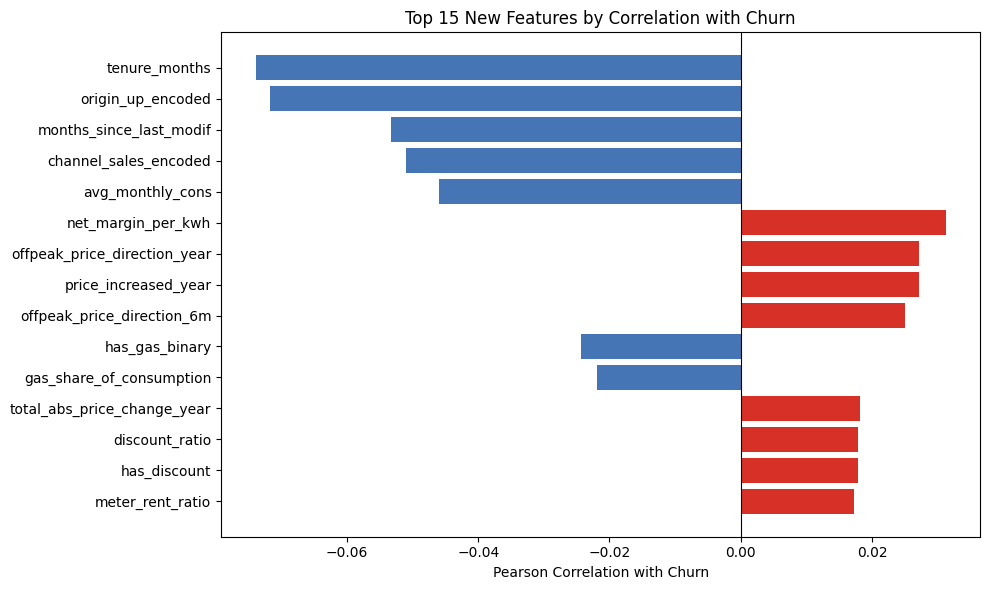

In [16]:
# Visualize the top correlations
top_n = 15
top_corr = corr_with_churn.head(top_n)

colors = ['#d73027' if c > 0 else '#4575b4' for c in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Churn')
ax.set_title(f'Top {top_n} New Features by Correlation with Churn')
plt.tight_layout()
plt.show()

In [17]:
# Null check on final dataset — confirm no NaN leaks from our feature engineering
null_counts = df_final[new_features].isnull().sum()
null_features = null_counts[null_counts > 0]

if null_features.empty:
    print('No nulls found in any engineered feature. Dataset is clean.')
else:
    print('Features with nulls (needs attention):')
    print(null_features)

No nulls found in any engineered feature. Dataset is clean.


---
## 5. Save final dataset

In [18]:
# Drop original raw date columns (already encoded into numeric features)
# and the original string categoricals (already encoded)
cols_to_drop = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
                'channel_sales', 'origin_up', 'has_gas']

df_model_ready = df_final.drop(columns=cols_to_drop)

print(f'Final model-ready dataset: {df_model_ready.shape[0]:,} rows x {df_model_ready.shape[1]} columns')

df_model_ready.to_csv('./data_for_modelling.csv', index=False)
print('Saved to data_for_modelling.csv')

Final model-ready dataset: 14,606 rows x 66 columns
Saved to data_for_modelling.csv
